In [1]:
import scanpy as sc
import drug2cell as d2c
import blitzgsea as blitz
import scanpy as sc
import matplotlib.pyplot as plt

Drug2cell offers two independent sets of utility functions for assessing gene group activity in single cell data - **scoring** and **overrepresentation/enrichment**. This notebook will demonstrate both on PBMC3K demo data.

In [2]:
sc.settings.verbosity=0 # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.n_jobs=4
sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(4,4))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(18,18))

%matplotlib inline

In [3]:
import pickle

with open('eczema_tdc_mcp_top200.pkl', 'rb') as f:
    gene_programme200 = pickle.load(f)



In [4]:
DATA_PREPARED=True
if not DATA_PREPARED:
    adata=sc.read_h5ad('/nfs/team361/ls34/inflow/final_adatas/adata_10ad_spatial.h5ad')
else:
    adata=sc.read_h5ad('/nfs/team361/ls34/inflow/final_adatas/adata_eczema_spatial_prepped.h5ad')

try:
    adata.obs["NICHE_NAMES"] = adata.obs["niche_name"]
except:
    adata
    
adata  


/software/cellgen/team298/ls34/drug2cell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 197487 × 1032
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', 'Site_status', 'info_id', 'sample', 'niche_name', 'lvl1', 'lvl0', 'veryfine_celltypes_new5', 'veryfine_celltypes_new5_incprolif', 'veryfine_celltypes', 'fine_celltypes_new', 'mod_celltypes_new', 'broad_celltypes_new', 'Site_status_binary', 'fine_celltypes', 'broad_celltypes', 'n_counts', 'n_genes', 'inflow_cell_type', 'inflow_biological_batch_ID', 'inflow_slice_ID', 'inflow_signaling_activity', 'leiden_res0.8', 'leiden_res0.5', 'NICHE_NAMES', 'spatial_niche', 'key_celltype_new'
    uns: 'NICHE_NAMES_colors', 'de_leiden', 'inflow_biological_batch_ID_colors', 'inflow_cell_type_colors',

In [5]:
adata.obs["spatial_niche"].value_counts()

spatial_niche
Epidermis_mid      69722
Stroma             28665
Neuromuscular      19319
Mac_T_cDC2         18958
Perivascular       13255
T_DC               11527
Epidermis_basal    11172
Blood vessel       10907
Epidermis_late      8255
Sweat gland         5707
Name: count, dtype: int64

In [6]:
adata=adata[adata.obs["spatial_niche"].str.startswith("T_DC")]
adata.obs["louvain"]=adata.obs["spatial_niche"]


/tmp/ipykernel_2835123/1288125846.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["louvain"]=adata.obs["spatial_niche"]


# Scoring

The scoring function efficiently computes the mean of the expression of each gene group in each cell. Can be directed to an appropriate location of log-normalised data via a combination of the `layer` and `use_raw` arguments.

By default, the function will load a set of ChEMBL drugs and their targets in a form distributed with the package.

We can use the new object to run differential expression analysis, getting gene groups that are up-regulated in particular clusters.

In [7]:
d2c.score(adata)# use_raw=True)


In [8]:
adata.uns["drug2cell"].var.index = [x.split("|")[1] for x in adata.uns["drug2cell"].var.index]
adata.uns["drug2cell"].var_names_make_unique()


,genes,all_genes
COLLAGENASE CLOSTRIDIUM HISTOLYTICUM,"COL11A1,COL18A1,COL4A1,COL4A2,COL4A4,COL5A1,CO...","COL1A2,COL1A1,COL18A1,COL5A3,COL11A2,COL27A1,C..."
BECAPLERMIN,"PDGFRA,PDGFRB","PDGFRA,PDGFRB"
IVACAFTOR,CFTR,CFTR
SODIUM FEREDETATE,NFE2L2,NFE2L2
LIOTHYRONINE SODIUM,HPGD,"ALDH1A1,BLM,THRA,HPGD,MCL1,BAZ2B,GMNN,POLB,THRB"
...,...,...
CEFMETAZOLE SODIUM,GLS,"POLH,BLM,GLS"
INDOMETHACIN SODIUM,PTGS1,"PTGS2,PTGS1"
RASAGILINE MESYLATE,MAOB,MAOB
ZILEUTON,ALOX5,"LTA4H,ALOX5,LMNA"


In [9]:
sc.tl.rank_genes_groups(adata.uns['drug2cell'], method="wilcoxon", groupby="Site_status")


In [10]:
rg = adata.uns["drug2cell"].uns["rank_genes_groups"]
lesional_genes = rg["names"]["Lesional"][:16].tolist()
lesional_genes


['INAMRINONE',
 'PYRITHIONE ZINC',
 'PSEUDOEPHEDRINE',
 'LEVONORDEFRIN',
 'CARBOPLATIN',
 'ETHOPROPAZINE HYDROCHLORIDE',
 'BITHIONOLATE SODIUM',
 'OXYTETRACYCLINE HYDROCHLORIDE',
 'DACTINOMYCIN',
 'TOFACITINIB CITRATE',
 'UPADACITINIB',
 'CHOLECALCIFEROL',
 'LANSOPRAZOLE',
 'MASOPROCOL',
 'SULFADIAZINE, SILVER',
 'FEXOFENADINE HYDROCHLORIDE']

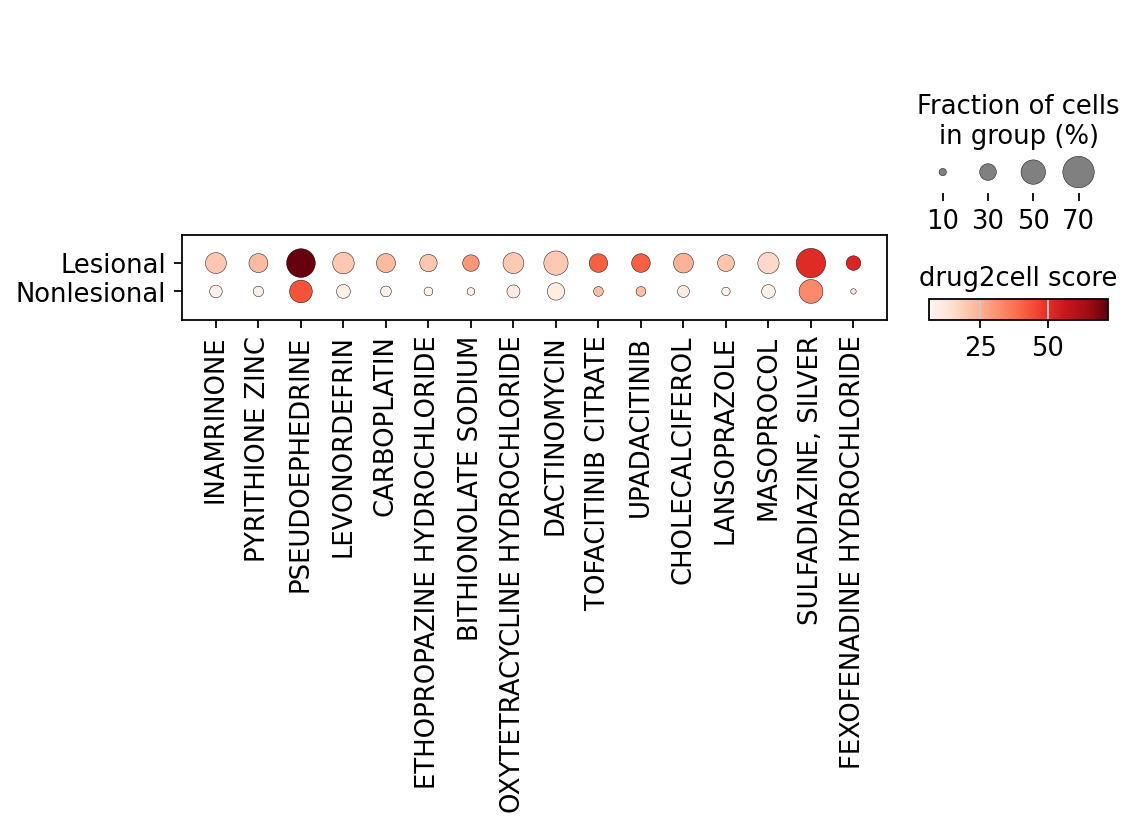

In [11]:
sc.pl.dotplot(
    adata.uns["drug2cell"],
    var_names=lesional_genes,
    groupby="Site_status",
    #standard_scale="var",
    save="drug2cell_lesional.pdf",
    colorbar_title="drug2cell score"
)

# SUPP FIG

In [12]:
if not DATA_PREPARED:
    adata=sc.read_h5ad('/nfs/team361/ls34/inflow/final_adatas/adata_10ad_spatial.h5ad')
else:
    adata=sc.read_h5ad('/nfs/team361/ls34/inflow/final_adatas/adata_eczema_spatial_prepped.h5ad')

adata=adata[adata.obs["spatial_niche"].str.startswith("T_DC")]
adata.obs["louvain"]=adata.obs["spatial_niche"]


/software/cellgen/team298/ls34/drug2cell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/tmp/ipykernel_2835123/3313022941.py:14: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["louvain"]=adata.obs["spatial_niche"]


In [13]:
d2c.score(adata)

In [14]:
sc.tl.rank_genes_groups(adata.uns['drug2cell'], method="wilcoxon", groupby="Site_status")


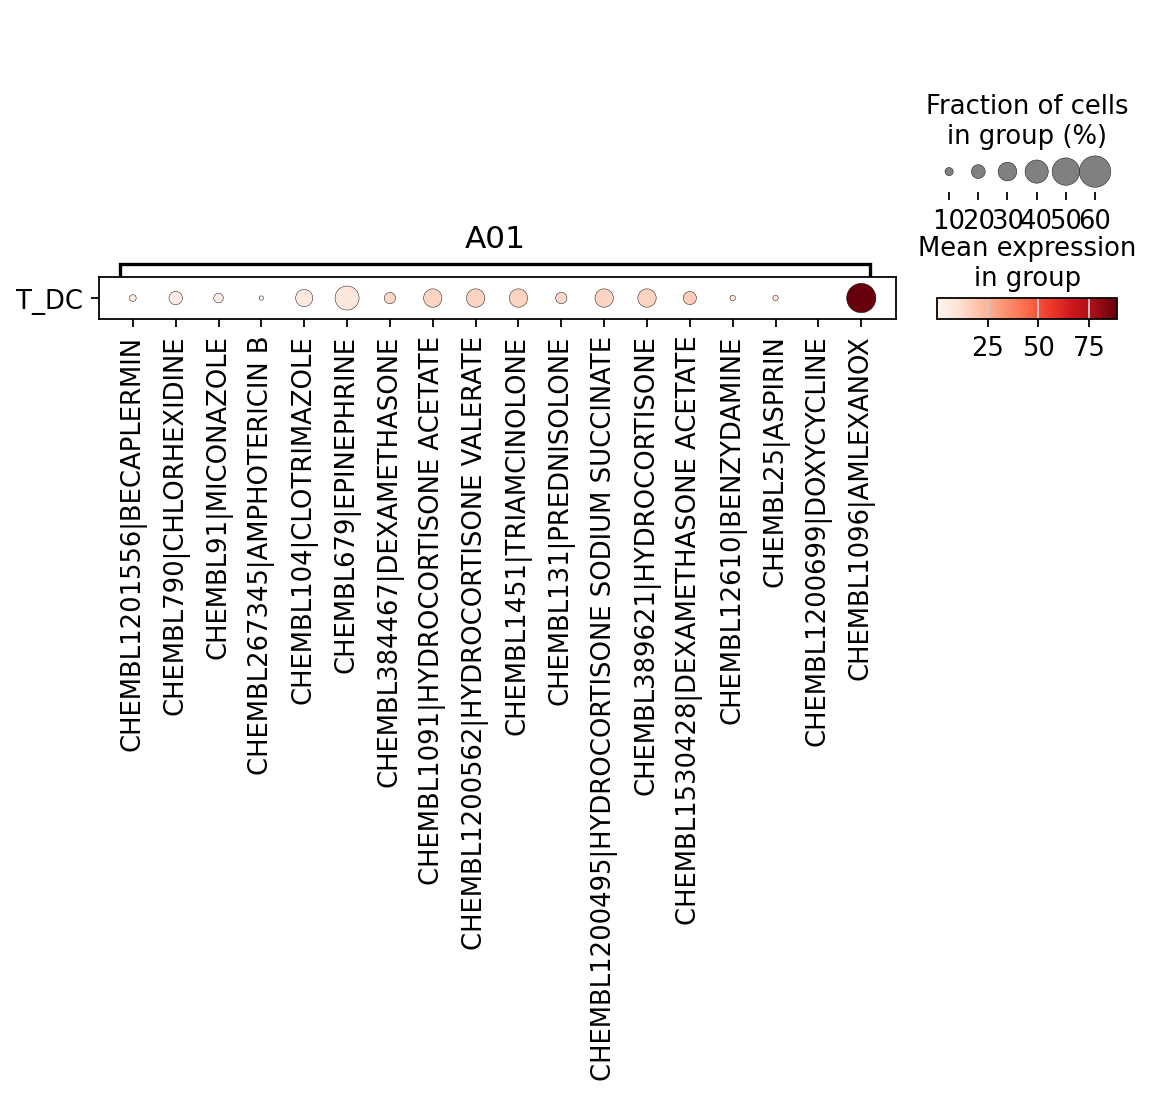

In [15]:
plot_args = d2c.util.prepare_plot_args(adata.uns['drug2cell'], categories=["A01",#"A02","A03", "B01","B02","B03", "C01", "C02", "D01", "D02"
                                                                          ])
sc.pl.dotplot(adata.uns['drug2cell'], 
             groupby="spatial_niche", #swap_axes=True,
                 # figsize=(8, 12),            # <--- SET SIZE HERE

              **plot_args
             )

